# BESS-JPL Sensitivity Analysis with ECOv002 Cal-Val

This notebook performs a sensitivity analysis of the BESS-JPL model using ECOSTRESS Collection 2 Cal-Val data. It loads input data, processes it through the BESS-JPL model, and visualizes the impact of input perturbations on latent heat flux. The notebook also generates figures for publication and explores the relationship between surface temperature and latent heat flux.

## Import Required Libraries and Functions

This cell imports all necessary libraries and functions for data processing, model execution, statistical analysis, and plotting. It includes custom modules for the BESS-JPL model, sensitivity analysis, and net radiation calculations, as well as standard scientific Python libraries.

In [1]:
import sys
import os
sys.path.insert(0, os.path.abspath(os.path.join(os.path.dirname("__file__"), '..')))

In [2]:
from typing import Callable
from os import makedirs
from os.path import join
import numpy as np
import pandas as pd
from BESS_JPL import process_BESS_table, load_ECOv002_calval_BESS_inputs
from monte_carlo_sensitivity import perturbed_run, sensitivity_analysis, divide_absolute_by_unperturbed
import matplotlib.pyplot as plt
from scipy.stats import mstats
import seaborn as sns
from matplotlib.ticker import FuncFormatter

## Set Normalization Function

This cell assigns the normalization function used to compare perturbed model outputs to the unperturbed baseline. The function `divide_absolute_by_unperturbed` is used for normalization in the sensitivity analysis.

In [3]:
normalization_function = divide_absolute_by_unperturbed

## Load and Filter Input Data

This cell loads the ECOSTRESS Cal-Val input data using a custom loader function. The resulting DataFrame is displayed for inspection.

In [4]:
input_df = load_ECOv002_calval_BESS_inputs()
input_df

,Unnamed: 0,ID,vegetation,climate,STICinst,BESSinst,MOD16inst,PTJPLSMinst,ETinst,ETinstUncertainty,...,ball_berry_intercept_C3,KG_climate,CI,canopy_height_meters,COT,AOT,Ca,wind_speed_mps,vapor_gccm,ozone_cm
0,0,US-NC3,ENF,Cfa,270.345200,78.53355,392.851840,307.021970,487.383423,118.916280,...,0.005267,3,0.282353,20.642902,0,0,400,0,0,0.3
1,1,US-Mi3,CVM,Dfb,232.141600,229.20093,640.118470,375.089300,106.825577,167.919460,...,0.009882,4,0.286275,0.000000,0,0,400,0,0,0.3
2,2,US-Mi3,CVM,Dfb,356.355740,335.23154,625.661700,284.686250,NaN,132.936340,...,0.009882,4,0.286275,0.000000,0,0,400,0,0,0.3
3,3,US-Mi3,CVM,Dfb,332.938400,326.68680,624.254330,251.414490,178.827545,141.132420,...,0.009882,4,0.286275,0.000000,0,0,400,0,0,0.3
4,4,US-Mi3,CVM,Dfb,286.854030,237.21654,511.082180,228.520170,154.791626,114.809410,...,0.009882,4,0.286275,0.000000,0,0,400,0,0,0.3
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1060,1060,US-xAE,GRA,Cfa,70.923310,172.37459,81.645230,15.282976,NaN,56.385185,...,0.015000,3,0.301961,0.000000,0,0,400,0,0,0.3
1061,1061,US-xAE,GRA,Cfa,116.543190,121.81641,65.469320,22.186659,NaN,40.509410,...,0.015000,3,0.301961,0.000000,0,0,400,0,0,0.3
1062,1062,US-xAE,GRA,Cfa,129.880100,0.00000,118.777240,55.343586,NaN,52.403820,...,0.015000,3,0.301961,0.000000,0,0,400,0,0,0.3
1063,1063,US-xAE,GRA,Cfa,2.707851,140.38632,126.490524,40.434025,NaN,57.769722,...,0.015000,3,0.301961,0.000000,0,0,400,0,0,0.3


## Process Input Data Through Model

This cell applies the processing function to the filtered input data, running it through the Verma net radiation and PT-JPL-SM model, and displays the resulting DataFrame.

In [5]:
processed = process_BESS_table(input_df)
processed

[2025-09-09 17:09:33 INFO] started extracting geometry from PT-JPL-SM input table
[2025-09-09 17:09:33 INFO] completed extracting geometry from PT-JPL-SM input table
[2025-09-09 17:09:33 INFO] started extracting time from PT-JPL-SM input table
[2025-09-09 17:09:33 INFO] completed extracting time from PT-JPL-SM input table
[2025-09-09 17:09:33 INFO] GEOS-5 FP working directory: /Users/gregoryhalverson/data/GEOS5FP
[2025-09-09 17:09:33 INFO] GEOS-5 FP download directory: ~/data/GEOS5FP
[2025-09-09 17:09:34 INFO] variable elevation_km min: 0.001 mean: 0.993 max: 3.504 nan: 0.00% (nan)
[2025-09-09 17:09:34 INFO] variable Ta_C min: -14.605 mean: 22.322 max: 39.710 nan: 0.00% (nan)
[2025-09-09 17:09:34 INFO] variable RH min: 0.273 mean: 0.427 max: 0.984 nan: 0.00% (nan)
[2025-09-09 17:09:34 INFO] variable NDVI_minimum min: -0.033 mean: 0.174 max: 0.591 nan: 0.00% (nan)
[2025-09-09 17:09:34 INFO] variable NDVI_maximum min: 0.314 mean: 0.628 max: 0.918 nan: 0.00% (nan)
[2025-09-09 17:09:34 INF

,Unnamed: 0,ID,vegetation,climate,STICinst,BESSinst,MOD16inst,PTJPLSMinst,ETinst,ETinstUncertainty,...,ozone_cm,GPP,GPP_daily,Rn_Wm2,Rn_soil_Wm2,Rn_canopy_Wm2,LE_Wm2,LE_soil_Wm2,LE_canopy_Wm2,G_Wm2
0,0,US-NC3,ENF,Cfa,270.345200,78.53355,392.851840,307.021970,487.383423,118.916280,...,0.3,16.306166,5.963702,543.574447,343.088141,200.486306,253.346657,69.342528,184.004129,37.045927
1,1,US-Mi3,CVM,Dfb,232.141600,229.20093,640.118470,375.089300,106.825577,167.919460,...,0.3,21.081704,8.623039,745.548400,568.929428,176.618973,225.765314,100.628336,125.136978,75.785976
2,2,US-Mi3,CVM,Dfb,356.355740,335.23154,625.661700,284.686250,NaN,132.936340,...,0.3,19.984935,8.120491,797.080000,595.207535,201.872465,346.807840,210.893323,135.914517,77.675719
3,3,US-Mi3,CVM,Dfb,332.938400,326.68680,624.254330,251.414490,178.827545,141.132420,...,0.3,24.216487,10.357271,734.801476,539.752171,195.049305,336.703432,207.202548,129.500884,69.717555
4,4,US-Mi3,CVM,Dfb,286.854030,237.21654,511.082180,228.520170,154.791626,114.809410,...,0.3,21.872922,10.242349,600.127613,441.941830,158.185783,259.677956,140.032444,119.645512,57.794590
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1060,1060,US-xAE,GRA,Cfa,70.923310,172.37459,81.645230,15.282976,NaN,56.385185,...,0.3,0.492826,0.193133,235.343693,165.684047,69.659646,46.681268,41.487784,5.193484,29.244793
1061,1061,US-xAE,GRA,Cfa,116.543190,121.81641,65.469320,22.186659,NaN,40.509410,...,0.3,1.259612,0.882347,266.190619,190.262323,75.928297,42.918736,31.172926,11.745809,32.896598
1062,1062,US-xAE,GRA,Cfa,129.880100,0.00000,118.777240,55.343586,NaN,52.403820,...,0.3,3.360783,2.404805,405.659567,266.716370,138.943197,47.368643,6.239409,41.129234,35.811898
1063,1063,US-xAE,GRA,Cfa,2.707851,140.38632,126.490524,40.434025,NaN,57.769722,...,0.3,1.986428,1.197719,314.897562,247.995207,66.902355,59.134543,48.996907,10.137635,44.868324


## Plot Unperturbed Comparison of Surface Temperature to Latent Heat Flux

This cell creates a scatter plot comparing ECOSTRESS surface temperature to PT-JPL-SM latent heat flux for the unperturbed data. The plot is saved as both JPEG and SVG files for publication or further analysis.

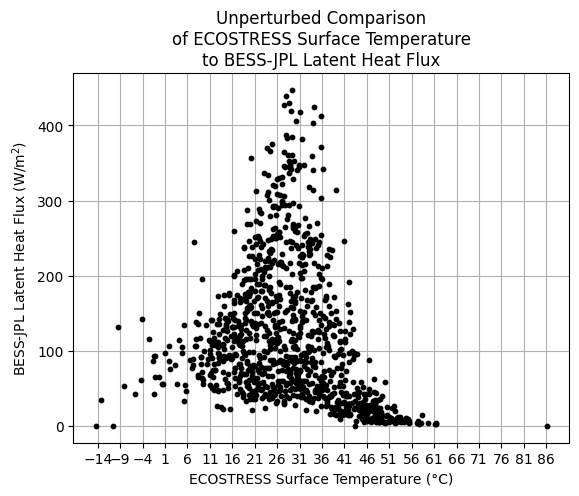

In [6]:
plt.xticks(range(int(min(processed.ST_C)), int(max(processed.ST_C)) + 1, 5))
plt.scatter(x=processed.ST_C, y=processed.LE_Wm2, color='black', s=10, zorder=5)
plt.grid(True, zorder=0)
plt.xlabel("ECOSTRESS Surface Temperature (°C)")
plt.ylabel("BESS-JPL Latent Heat Flux (W/m$^2$)")
plt.title("Unperturbed Comparison\nof ECOSTRESS Surface Temperature\nto BESS-JPL Latent Heat Flux")

plt.savefig("Unperturbed Comparison of ECOSTRESS Surface Temperature to BESS-JPL Latent Heat Flux.jpeg", format='jpeg', bbox_inches='tight')
plt.savefig("Unperturbed Comparison of ECOSTRESS Surface Temperature to BESS-JPL Latent Heat Flux.svg", format='svg', bbox_inches='tight')

plt.show()

## Further Filter Input Data and Check Temperature Range

This cell applies additional filters to the input data, ensuring only valid `fAPARmax` and `NDVI` values are included. It also checks the minimum and maximum surface temperature values in the filtered dataset.

In [7]:
# input_df = pd.read_csv(input_filename)
input_df = load_ECOv002_calval_BESS_inputs()

if "Ta" in input_df and "Ta_C" not in input_df:
    # input_df.rename({"Ta": "Ta_C"}, inplace=True)
    input_df["Ta_C"] = input_df["Ta"]

input_df = input_df[input_df.NDVI.apply(lambda NDVI: NDVI > 0.05)]

np.nanmin(input_df.ST_C), np.nanmax(input_df.ST_C)

(-13.189999999999998, 86.11000000000001)

## Check Number of Valid Input Rows

This cell displays the number of rows remaining in the input DataFrame after all filtering steps, confirming the size of the dataset used for analysis.

In [8]:
len(input_df)

1063

## Run Perturbed Model Analysis

This cell sets up the input and output variables for the sensitivity analysis and runs the `perturbed_run` function, which perturbs the input variable and observes the effect on the output variable using the PT-JPL-SM model. The results are displayed for further analysis.

In [9]:
input_variable = "ST_C"
output_variable = "LE_Wm2"

results = perturbed_run(
    input_df=input_df, 
    input_variable=input_variable, 
    output_variable=output_variable, 
    forward_process=process_BESS_table,
    normalization_function=normalization_function
)

results

[2025-09-09 17:09:34 INFO] tarting Monte Carlo perturbed run
[2025-09-09 17:09:34 INFO] calculating standard deviation of input variable: ST_C
[2025-09-09 17:09:34 INFO] input variable ST_C standard deviation: 12.285657205245933
[2025-09-09 17:09:34 INFO] starting forward process
[2025-09-09 17:09:34 INFO] started extracting geometry from PT-JPL-SM input table
[2025-09-09 17:09:34 INFO] completed extracting geometry from PT-JPL-SM input table
[2025-09-09 17:09:34 INFO] started extracting time from PT-JPL-SM input table
[2025-09-09 17:09:34 INFO] completed extracting time from PT-JPL-SM input table
[2025-09-09 17:09:34 INFO] GEOS-5 FP working directory: /Users/gregoryhalverson/data/GEOS5FP
[2025-09-09 17:09:34 INFO] GEOS-5 FP download directory: ~/data/GEOS5FP
[2025-09-09 17:09:34 INFO] variable elevation_km min: 0.001 mean: 0.994 max: 3.504 nan: 0.00% (nan)
[2025-09-09 17:09:34 INFO] variable Ta_C min: -14.605 mean: 22.380 max: 39.710 nan: 0.00% (nan)
[2025-09-09 17:09:34 INFO] variabl

,input_variable,output_variable,input_unperturbed,input_perturbation,input_perturbation_std,input_perturbed,output_unperturbed,output_perturbation,output_perturbation_std,output_perturbed
0,ST_C,LE_Wm2,31.95,5.888720,0.184310,37.83872,253.346657,-50.994056,0.201282,202.352601
1,ST_C,LE_Wm2,31.95,-21.314681,0.667126,10.635319,253.346657,-32.956434,0.130084,220.390223
2,ST_C,LE_Wm2,31.95,18.337178,0.573934,50.287178,253.346657,-201.715046,0.796202,51.631611
3,ST_C,LE_Wm2,31.95,9.741003,0.304883,41.691003,253.346657,-110.002183,0.434196,143.344474
4,ST_C,LE_Wm2,31.95,-21.655237,0.677785,10.294763,253.346657,-34.401103,0.135787,218.945554
...,...,...,...,...,...,...,...,...,...,...
106295,ST_C,LE_Wm2,41.61,13.410130,0.322281,55.02013,40.483396,-22.285773,0.550492,18.197622
106296,ST_C,LE_Wm2,41.61,-4.238651,0.101866,37.371349,40.483396,20.73926,0.512291,61.222655
106297,ST_C,LE_Wm2,41.61,0.783984,0.018841,42.393984,40.483396,-2.105501,0.052009,38.377895
106298,ST_C,LE_Wm2,41.61,16.051511,0.385761,57.661511,40.483396,-23.942088,0.591405,16.541308


## Filter Out NaN Results

This cell removes any rows with missing values from the perturbed results to ensure only valid data points are used in subsequent analysis and plotting.

In [10]:
filtered_results = results.dropna()
filtered_results

,input_variable,output_variable,input_unperturbed,input_perturbation,input_perturbation_std,input_perturbed,output_unperturbed,output_perturbation,output_perturbation_std,output_perturbed
0,ST_C,LE_Wm2,31.95,5.888720,0.184310,37.83872,253.346657,-50.994056,0.201282,202.352601
1,ST_C,LE_Wm2,31.95,-21.314681,0.667126,10.635319,253.346657,-32.956434,0.130084,220.390223
2,ST_C,LE_Wm2,31.95,18.337178,0.573934,50.287178,253.346657,-201.715046,0.796202,51.631611
3,ST_C,LE_Wm2,31.95,9.741003,0.304883,41.691003,253.346657,-110.002183,0.434196,143.344474
4,ST_C,LE_Wm2,31.95,-21.655237,0.677785,10.294763,253.346657,-34.401103,0.135787,218.945554
...,...,...,...,...,...,...,...,...,...,...
106295,ST_C,LE_Wm2,41.61,13.410130,0.322281,55.02013,40.483396,-22.285773,0.550492,18.197622
106296,ST_C,LE_Wm2,41.61,-4.238651,0.101866,37.371349,40.483396,20.73926,0.512291,61.222655
106297,ST_C,LE_Wm2,41.61,0.783984,0.018841,42.393984,40.483396,-2.105501,0.052009,38.377895
106298,ST_C,LE_Wm2,41.61,16.051511,0.385761,57.661511,40.483396,-23.942088,0.591405,16.541308


## Plot Change in Surface Temperature vs Latent Heat Flux

This cell generates a scatter plot showing the relationship between changes in surface temperature and changes in PT-JPL-SM latent heat flux due to input perturbations. The plot is saved as JPEG and SVG files.

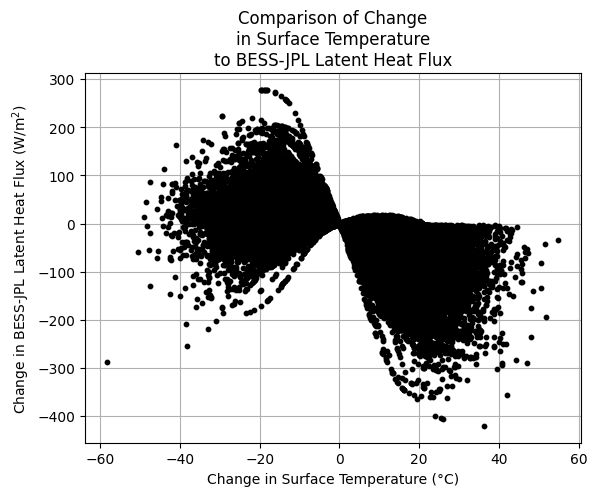

In [11]:
# plt.xticks(range(int(min(processed.ST_C)), int(max(processed.ST_C)) + 1, 5))
# plt.ylim(-350, 150)
plt.scatter(x=results.input_perturbation, y=results.output_perturbation, color='black', s=10, zorder=5)  # Adjust the 's' parameter to make dots thinner
plt.grid(True, zorder=0)
plt.xlabel("Change in Surface Temperature (°C)")
plt.ylabel("Change in BESS-JPL Latent Heat Flux (W/m$^2$)")
plt.title("Comparison of Change\nin Surface Temperature\nto BESS-JPL Latent Heat Flux")

plt.savefig("Comparison of Change in Surface Temperature to BESS-JPL Latent Heat Flux.jpeg", format='jpeg', bbox_inches='tight')
plt.savefig("Comparison of Change in Surface Temperature to BESS-JPL Latent Heat Flux.svg", format='svg', bbox_inches='tight')

plt.show()

## Compute Correlation Between Input and Output Perturbations

This cell calculates the Pearson correlation coefficient between the standardized input and output perturbations, quantifying the strength of their linear relationship.

In [12]:
correlation = mstats.pearsonr(
    np.array(filtered_results.input_perturbation_std).astype(np.float64), 
    np.array(filtered_results.output_perturbation_std).astype(np.float64)
)[0]

correlation

0.01981606113502872

## Run Full Sensitivity Analysis for Multiple Inputs

This cell performs a comprehensive sensitivity analysis by perturbing several input variables (surface temperature, NDVI, albedo, air temperature, relative humidity) and measuring their effect on latent heat flux. The results are summarized in a DataFrame.

In [13]:
input_variables = ["ST_C", "NDVI", "albedo", "Ta_C", "RH"]
output_variables = ["LE_Wm2"]

perturbation_df, sensitivity_metrics_df = sensitivity_analysis(
    input_df=input_df,
    input_variables=input_variables,
    output_variables=output_variables,
    forward_process=process_BESS_table,
    normalization_function=normalization_function
)

sensitivity_metrics_df

[2025-09-09 17:09:44 INFO] tarting Monte Carlo perturbed run
[2025-09-09 17:09:44 INFO] calculating standard deviation of input variable: ST_C
[2025-09-09 17:09:44 INFO] input variable ST_C standard deviation: 12.285657205245933
[2025-09-09 17:09:44 INFO] starting forward process
[2025-09-09 17:09:44 INFO] started extracting geometry from PT-JPL-SM input table
[2025-09-09 17:09:44 INFO] completed extracting geometry from PT-JPL-SM input table
[2025-09-09 17:09:44 INFO] started extracting time from PT-JPL-SM input table
[2025-09-09 17:09:44 INFO] completed extracting time from PT-JPL-SM input table
[2025-09-09 17:09:44 INFO] GEOS-5 FP working directory: /Users/gregoryhalverson/data/GEOS5FP
[2025-09-09 17:09:44 INFO] GEOS-5 FP download directory: ~/data/GEOS5FP
[2025-09-09 17:09:44 INFO] variable elevation_km min: 0.001 mean: 0.994 max: 3.504 nan: 0.00% (nan)
[2025-09-09 17:09:44 INFO] variable Ta_C min: -14.605 mean: 22.380 max: 39.710 nan: 0.00% (nan)
[2025-09-09 17:09:44 INFO] variabl

/opt/homebrew/Caskroom/miniforge/base/envs/BESS-JPL/lib/python3.11/site-packages/monte_carlo_sensitivity/sensitivity_analysis.py:77: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  perturbation_df = pd.concat([perturbation_df, run_results])
/opt/homebrew/Caskroom/miniforge/base/envs/BESS-JPL/lib/python3.11/site-packages/monte_carlo_sensitivity/sensitivity_analysis.py:89: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  sensitivity_metrics_df = pd.concat([sensitivity_metrics_df, pd.DataFrame([[


[2025-09-09 17:09:54 INFO] variable Ps_Pa min: 64923.167 mean: 90406.157 max: 101313.196 nan: 0.00% (nan)
[2025-09-09 17:09:54 INFO] variable VPD_Pa min: 9.430 mean: 1745.964 max: 4717.745 nan: 0.00% (nan)
[2025-09-09 17:09:54 INFO] variable RH min: 0.273 mean: 0.426 max: 0.985 nan: 0.00% (nan)
[2025-09-09 17:09:54 INFO] variable desTa min: 16.249 mean: 177.138 max: 387.676 nan: 0.00% (nan)
[2025-09-09 17:09:54 INFO] variable ddesTa min: 1.197 mean: 9.183 max: 17.906 nan: 0.00% (nan)
[2025-09-09 17:09:54 INFO] variable gamma min: 42.603 mean: 60.196 max: 68.164 nan: 0.00% (nan)
[2025-09-09 17:09:54 INFO] variable Cp min: 1005.900 mean: 1012.868 max: 1022.896 nan: 0.00% (nan)
[2025-09-09 17:09:54 INFO] variable rhoa min: 0.776 mean: 1.067 max: 1.314 nan: 0.00% (nan)
[2025-09-09 17:09:54 INFO] variable epsa min: 0.663 mean: 0.769 max: 0.873 nan: 0.00% (nan)
[2025-09-09 17:09:54 INFO] variable R min: 6.213 mean: 24.201 max: 32.659 nan: 0.00% (nan)
[2025-09-09 17:09:54 INFO] variable Rc mi

/Users/gregoryhalverson/Projects/BESS-JPL/BESS_JPL/LAI_from_NDVI.py:26: RuntimeWarning: divide by zero encountered in log
  LAI = rt.clip(-np.log(1 - fIPAR) * (1 / KPAR), min_LAI, max_LAI)


[2025-09-09 17:10:03 INFO] variable APAR_shaded min: 0.000 mean: 40.886 max: 185.697 nan: 13.20% (nan)
[2025-09-09 17:10:03 INFO] variable ASW_sunlit min: 56.844 mean: 223.879 max: 564.178 nan: 13.20% (nan)
[2025-09-09 17:10:03 INFO] variable ASW_shaded min: 0.122 mean: 25.759 max: 300.483 nan: 13.20% (nan)
[2025-09-09 17:10:03 INFO] variable ASW_soil min: 15.526 mean: 438.236 max: 844.613 nan: 13.20% (nan)
[2025-09-09 17:10:03 INFO] variable G min: 0.000 mean: 51.976 max: 107.475 nan: 13.20% (nan)
[2025-09-09 17:10:03 INFO] variable GPP_C3 min: 0.000 mean: 10.491 max: 40.000 nan: 13.20% (nan)
[2025-09-09 17:10:03 INFO] variable LE_C3 min: 0.000 mean: 112.815 max: 527.381 nan: 0.00% (nan)
[2025-09-09 17:10:03 INFO] variable LE_soil_C3 min: 0.000 mean: 50.849 max: 285.064 nan: 0.00% (nan)
[2025-09-09 17:10:03 INFO] variable LE_canopy_C3 min: 0.000 mean: 61.966 max: 484.131 nan: 0.00% (nan)
[2025-09-09 17:10:03 INFO] variable Rn_C3 min: 0.000 mean: 442.391 max: 1000.000 nan: 0.00% (nan)


/Users/gregoryhalverson/Projects/BESS-JPL/BESS_JPL/meteorology.py:166: RuntimeWarning: invalid value encountered in sqrt
  epsa0 = 0.605 + 0.048 * (Ea_Pa / 100) ** 0.5  # [-]
/Users/gregoryhalverson/Projects/BESS-JPL/BESS_JPL/canopy_energy_balance.py:117: RuntimeWarning: divide by zero encountered in divide
  Ci = Ca - 1.6 * An / gs1  # [umol./mol]
/Users/gregoryhalverson/Projects/BESS-JPL/BESS_JPL/canopy_energy_balance.py:123: RuntimeWarning: divide by zero encountered in divide
  rs = 1.0 / (gs1 / cf * 1e-2)  # [s m-1]
/Users/gregoryhalverson/Projects/BESS-JPL/BESS_JPL/canopy_energy_balance.py:117: RuntimeWarning: invalid value encountered in divide
  Ci = Ca - 1.6 * An / gs1  # [umol./mol]


[2025-09-09 17:10:31 INFO] variable GPP_C4 min: 0.000 mean: 13.167 max: 50.000 nan: 0.00% (nan)
[2025-09-09 17:10:31 INFO] variable LE_C4 min: 0.000 mean: 123.173 max: 674.628 nan: 0.00% (nan)
[2025-09-09 17:10:31 INFO] variable LE_soil_C4 min: 0.000 mean: 63.397 max: 439.869 nan: 0.00% (nan)
[2025-09-09 17:10:31 INFO] variable LE_canopy_C4 min: 0.000 mean: 59.775 max: 444.772 nan: 0.00% (nan)
[2025-09-09 17:10:31 INFO] variable Rn_C4 min: 0.000 mean: 498.181 max: 1000.000 nan: 0.00% (nan)
[2025-09-09 17:10:31 INFO] variable Rn_soil_C4 min: 0.000 mean: 370.017 max: 702.770 nan: 0.00% (nan)
[2025-09-09 17:10:31 INFO] variable Rn_canopy_C4 min: 0.000 mean: 128.210 max: 608.768 nan: 0.00% (nan)
[2025-09-09 17:10:32 INFO] completed forward process for perturbed input
[2025-09-09 17:10:32 INFO] normalizing output perturbations
[2025-09-09 17:10:32 INFO] Monte Carlo run complete


,input_variable,output_variable,metric,value
0,ST_C,LE_Wm2,correlation,0.021640
0,ST_C,LE_Wm2,r2,0.000468
0,ST_C,LE_Wm2,mean_normalized_change,0.402443
0,NDVI,LE_Wm2,correlation,0.642921
0,NDVI,LE_Wm2,r2,0.413347
0,NDVI,LE_Wm2,mean_normalized_change,0.392024
0,albedo,LE_Wm2,correlation,0.511432
0,albedo,LE_Wm2,r2,0.261563
0,albedo,LE_Wm2,mean_normalized_change,0.044081
0,Ta_C,LE_Wm2,correlation,0.030310


## Plot Sensitivity Magnitude Bar Chart

This cell creates a bar chart showing the average percent change in latent heat flux for each input variable, visualizing the magnitude of model sensitivity to each input. The plot is saved as JPEG and SVG files with the BESS-JPL label.

/var/folders/bv/410kt7f93x78j9dww00h1pz80000gn/T/ipykernel_19422/3108202059.py:4: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(["Surface\nTemperature", "NDVI", "Albedo", "Air\nTemperature", "Relative\nHumidity"])


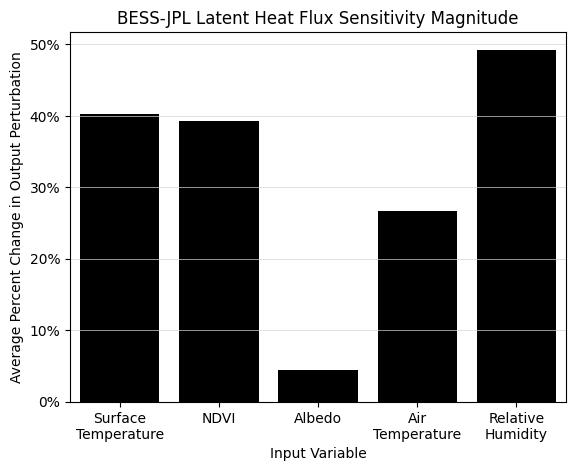

In [14]:
df = sensitivity_metrics_df
df = df[(df.output_variable == "LE_Wm2") & (df.metric == "mean_normalized_change")]
ax = sns.barplot(x=df.input_variable, y=df.value * 100, color='black')
ax.set_xticklabels(["Surface\nTemperature", "NDVI", "Albedo", "Air\nTemperature", "Relative\nHumidity"])
plt.xlabel("Input Variable")
plt.ylabel("Average Percent Change in Output Perturbation")
plt.title("BESS-JPL Latent Heat Flux Sensitivity Magnitude")
# plt.ylim(0, 160)  # Set y-axis range from 0 to 160
plt.grid(axis='y', color='lightgray', linestyle='-', linewidth=0.5)  # Add light gray horizontal gridlines only

# Add percent sign to y-axis tick labels
ax.yaxis.set_major_formatter(FuncFormatter(lambda y, _: f'{int(y)}%'))

plt.savefig("BESS-JPL Latent Heat Flux Sensitivity Magnitude.jpeg", format='jpeg', bbox_inches='tight')
plt.savefig("BESS-JPL Latent Heat Flux Sensitivity Magnitude.svg", format='svg', bbox_inches='tight')

plt.show()

## Plot Sensitivity Correlation Bar Chart

This cell generates a bar chart showing the correlation between input perturbations and output perturbations for each input variable, highlighting which inputs most strongly influence latent heat flux. The plot is saved as JPEG and SVG files with the PT-JPL-SM label.

/var/folders/bv/410kt7f93x78j9dww00h1pz80000gn/T/ipykernel_19422/255685249.py:4: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(["Surface\nTemperature", "NDVI", "Albedo", "Air\nTemperature", "Relative\nHumidity"])


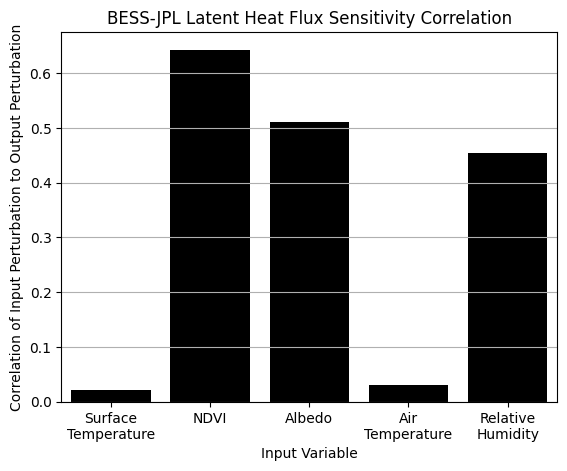

In [15]:
df = sensitivity_metrics_df
df = df[(df.output_variable == "LE_Wm2") & (df.metric == "correlation")]
ax = sns.barplot(x=df.input_variable, y=df.value, color='black')
ax.set_xticklabels(["Surface\nTemperature", "NDVI", "Albedo", "Air\nTemperature", "Relative\nHumidity"])
# plt.ylim(0, 0.8)
plt.xlabel("Input Variable")
plt.ylabel("Correlation of Input Perturbation to Output Perturbation")
plt.title("BESS-JPL Latent Heat Flux Sensitivity Correlation")
plt.grid(axis='y')  # Add horizontal gridlines

plt.savefig("BESS-JPL Latent Heat Flux Sensitivity Correlation.jpeg", format='jpeg', bbox_inches='tight')
plt.savefig("BESS-JPL Latent Heat Flux Sensitivity Correlation.svg", format='svg', bbox_inches='tight')

plt.show()

## Summary and Next Steps

This notebook demonstrated a full sensitivity analysis workflow for the PT-JPL-SM model using ECOSTRESS Cal-Val data. Key results include the identification of input variables with the greatest influence on latent heat flux. Next steps could include further exploration of model parameters, additional visualizations, or application to other datasets.